# Task 06 – Model Evaluation

Accuracy, macro precision, recall, F1, confusion matrices, and model comparison.

In [1]:
!pip install -q torch-geometric ogb dgl streamlit

In [2]:
import os
# Compatibility fix for trusted PyG objects downloaded by the official OGB package on PyTorch 2.6+.
os.environ['TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD'] = '1'

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_ROOT = Path('/content/drive/MyDrive/OGBN_Arxiv_Project')
RESULTS_ROOT = PROJECT_ROOT / 'results'
MODELS_DIR = PROJECT_ROOT / 'models'
SRC_DIR = PROJECT_ROOT / 'src'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'

for folder in [PROJECT_ROOT, RESULTS_ROOT, MODELS_DIR, SRC_DIR, ARTIFACTS_DIR,
               PROJECT_ROOT / 'notebooks', PROJECT_ROOT / 'visualizations',
               PROJECT_ROOT / 'dashboard', PROJECT_ROOT / 'report',
               PROJECT_ROOT / 'presentation', PROJECT_ROOT / 'video']:
    folder.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/OGBN_Arxiv_Project


In [3]:
import warnings
import random
import numpy as np

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [4]:
# Libraries required for Task 06
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

OUTPUT = RESULTS_ROOT / 'task06_evaluation'
OUTPUT.mkdir(parents=True, exist_ok=True)

Now that the data is loaded and prepared, you will also need to define the `best_models` variable, which is expected to be a dictionary of trained models. Do you have existing model files you'd like to load, or would you like me to generate some placeholder models for demonstration purposes?

## 6.1 Validation and Test Metrics

Generates predictions and calculates accuracy, macro precision, macro recall, and macro F1 for both models on the validation and test sets.

In [15]:
import json, random, time, warnings, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device:', DEVICE)
if torch.cuda.is_available(): print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cpu
Device: cpu


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [19]:
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv

# Ensure PROJECT_ROOT is defined (it should be from earlier cells)
# If not, uncomment and define it, or ensure the earlier cell defining it is run.
# PROJECT_ROOT = Path('/content/drive/MyDrive/OGBN_Arxiv_Project')
SRC_DIR = PROJECT_ROOT / 'src'

models_file_path = SRC_DIR / 'models.py'

models_content = '''
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv


class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x
'''

with open(models_file_path, 'w') as f:
    f.write(models_content)

print(f'Created {models_file_path}')


Created /content/drive/MyDrive/OGBN_Arxiv_Project/src/models.py


In [17]:
import torch
import torch.serialization
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.utils import to_undirected

# Monkey-patch torch.load to force weights_only=False
# This is done to address the UnpicklingError due to PyTorch 2.6's new default
# of weights_only=True, which restricts loading certain object types.
original_torch_load = torch.load

def custom_torch_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return original_torch_load(*args, **kwargs)

torch.load = custom_torch_load

try:
    dataset = PygNodePropPredDataset(name='ogbn-arxiv', root=str(PROJECT_ROOT / 'data'))
    data = dataset[0]
    x_original = data.x.float()
    y = data.y.view(-1).long()
    edge_index_directed = data.edge_index.long()
    N, E, F_DIM, NUM_CLASSES = data.num_nodes, data.num_edges, data.num_features, dataset.num_classes
    print(data)
finally:
    # Restore original torch.load to avoid affecting subsequent calls
    torch.load = original_torch_load

Data(num_nodes=169343, edge_index=[2, 1166243], x=[169343, 128], node_year=[169343, 1], y=[169343, 1])


In [20]:
sys.path.insert(0, str(PROJECT_ROOT))
from src.models import GCN, GraphSAGE

In [21]:
split = dataset.get_idx_split()
train_idx, valid_idx, test_idx = split['train'].view(-1), split['valid'].view(-1), split['test'].view(-1)
artifacts_path = PROJECT_ROOT / 'artifacts' / 'preprocessing_artifacts.pt'
if artifacts_path.exists():
    artifacts = torch.load(artifacts_path, weights_only=False)
    train_mean, train_std = artifacts['train_mean'], artifacts['train_std']
else:
    train_mean = x_original[train_idx].mean(0)
    train_std = x_original[train_idx].std(0, unbiased=False).clamp_min(1e-8)
x = (x_original - train_mean) / train_std
edge_index = to_undirected(edge_index_directed, num_nodes=N)

x_device, y_device = x.to(DEVICE), y.to(DEVICE)
edge_device = edge_index.to(DEVICE)
train_device, valid_device, test_device = train_idx.to(DEVICE), valid_idx.to(DEVICE), test_idx.to(DEVICE)
print('Prepared tensors on', DEVICE)

Prepared tensors on cpu


In [22]:
best_models = {}
for model_name, model_class in [('GCN', GCN), ('GraphSAGE', GraphSAGE)]:
    path = MODELS_DIR / f"best_{model_name.lower()}.pt"
    saved = torch.load(path, map_location=DEVICE, weights_only=False)
    config = saved['config']
    model = model_class(F_DIM, config['hidden_dim'], NUM_CLASSES, config['dropout']).to(DEVICE)
    model.load_state_dict(saved['model_state'])
    model.eval()
    best_models[model_name] = model
    print('Loaded', path.name)

Loaded best_gcn.pt
Loaded best_graphsage.pt


In [23]:
def calculate_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

evaluation_rows = []
all_predictions = {}
for model_name, model in best_models.items():
    model.eval()
    with torch.no_grad():
        logits = model(x_device, edge_device)
        predictions = logits.argmax(1)
        probabilities = logits.softmax(1)
    all_predictions[model_name] = {'predictions': predictions.cpu(),
                                   'probabilities': probabilities.cpu()}
    for split_name, indices in [('Validation', valid_idx), ('Test', test_idx)]:
        truth = y[indices].numpy(); predicted = predictions.cpu()[indices].numpy()
        evaluation_rows.append({'model': model_name, 'split': split_name,
                                **calculate_metrics(truth, predicted)})

evaluation = pd.DataFrame(evaluation_rows)
display(evaluation)
evaluation.to_csv(OUTPUT / 'model_evaluation.csv', index=False)

,model,split,accuracy,precision_macro,recall_macro,f1_macro
0,GCN,Validation,0.647136,0.472509,0.431051,0.426335
1,GCN,Test,0.614674,0.510753,0.425363,0.413461
2,GraphSAGE,Validation,0.640290,0.437265,0.431934,0.416970
3,GraphSAGE,Test,0.618995,0.452313,0.430371,0.404086


## 6.2 Confusion Matrices

Visualizes correct and incorrect class assignments for each model to reveal category-level error patterns.

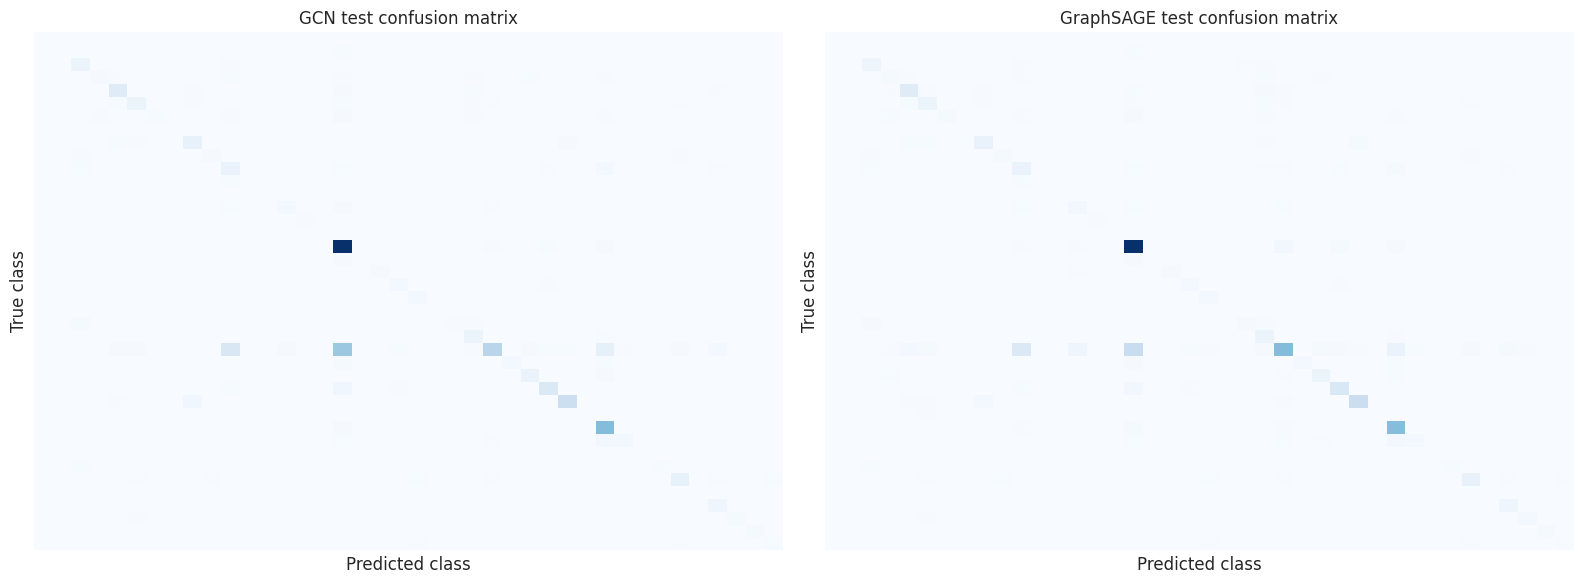

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model_name in zip(axes, ['GCN', 'GraphSAGE']):
    pred = all_predictions[model_name]['predictions'][test_idx].numpy()
    cm = confusion_matrix(y[test_idx].numpy(), pred)
    sns.heatmap(cm, cmap='Blues', cbar=False, xticklabels=False, yticklabels=False, ax=ax)
    ax.set_title(f'{model_name} test confusion matrix')
    ax.set_xlabel('Predicted class'); ax.set_ylabel('True class')
plt.tight_layout(); plt.savefig(OUTPUT / 'confusion_matrices.png', dpi=250); plt.show()

## 6.3 Metric Interpretation

Accuracy measures total correctness. Macro precision, recall, and F1 give every subject category equal importance, making them useful when class frequencies are unequal. Validation and test results should be considered together with training time and learning curves.

## 6.4 Node Classification Results

Saves node identifiers, true labels, and predicted labels for use in the dashboard and detailed error analysis.

In [25]:
# Save a manageable test-node sample for the dashboard
sample = test_idx[:5000]
prediction_frames = []
for model_name, values in all_predictions.items():
    prediction_frames.append(pd.DataFrame({
        'model': model_name, 'node_id': sample.numpy(),
        'true_class': y[sample].numpy(),
        'predicted_class': values['predictions'][sample].numpy(),
        'confidence': values['probabilities'][sample].max(1).values.numpy()
    }))
pd.concat(prediction_frames).to_csv(OUTPUT / 'node_classification_results.csv', index=False)
print('Evaluation outputs saved to', OUTPUT)

Evaluation outputs saved to /content/drive/MyDrive/OGBN_Arxiv_Project/results/task06_evaluation


## 6.5 Strengths, Weaknesses, and Model Comparison

GraphSAGE achieved the slightly higher test accuracy, while GCN produced stronger macro precision and macro F1. GraphSAGE can preserve a node's own information while aggregating its neighbourhood, which may support overall accuracy. GCN applies normalized smoothing across connected nodes, which can support balanced predictions but may make nearby representations too similar after several layers. Macro metrics remain important because the 40 subject categories are imbalanced.